<a href="https://colab.research.google.com/github/ms-solly/idbi-hackathon-2026/blob/main/notebooks/03_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic Regression Baseline Model**

### **Objective**

This notebook develops a baseline Logistic Regression model for predicting loan default using the preprocessed Give Me Some Credit dataset.

Objectives:
- Load the processed datasets
- Train a Logistic Regression model
- Evaluate performance
- Visualize results
- Establish a baseline for comparison with XGBoost

In [1]:
!git clone https://github.com/ms-solly/idbi-hackathon-2026.git

Cloning into 'idbi-hackathon-2026'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 36 (delta 8), reused 24 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 14.60 MiB | 17.18 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [2]:
%cd idbi-hackathon-2026

/content/idbi-hackathon-2026


In [3]:
!ls

data  notebooks  requirements.txt


In [9]:
!ls data/processed

X_test.csv  X_train.csv  y_test.csv  y_train.csv


In [4]:
!find . -name "*.csv"

./data/cs-training.csv
./data/X_train.csv
./data/processed/X_train.csv
./data/processed/X_test.csv
./data/processed/y_train.csv
./data/processed/y_test.csv
./data/cs-test.csv


In [6]:
import os
print(os.getcwd())

/content/idbi-hackathon-2026


In [7]:
!find . -name "X_train.csv"

./data/X_train.csv
./data/processed/X_train.csv


**Import Libraries**

In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

**Load the Preprocessed Dataset**

In [10]:
import pandas as pd

X_train = pd.read_csv("./data/processed/X_train.csv")
X_test = pd.read_csv("./data/processed/X_test.csv")

y_train = pd.read_csv("./data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("./data/processed/y_test.csv").squeeze()

print(X_train.shape)
print(X_test.shape)

(223958, 10)
(30000, 10)


Step 1: **Train the Logistic Regression model**

In [13]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


**Make Predictions**

In [14]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

**Evaluate the Model**

In [15]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7554666666666666
Precision: 0.16982534373838723
Recall   : 0.6837905236907731
F1 Score : 0.27207779321293907
ROC AUC  : 0.7950926577109645


**Classification Report**

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.76      0.85     27995
           1       0.17      0.68      0.27      2005

    accuracy                           0.76     30000
   macro avg       0.57      0.72      0.56     30000
weighted avg       0.92      0.76      0.81     30000



**Confusion Matrix**

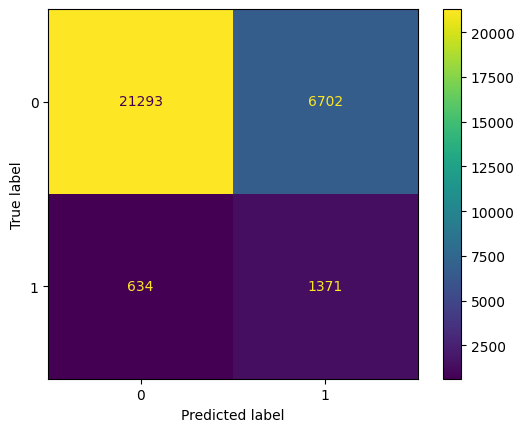

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

**ROC Curve**

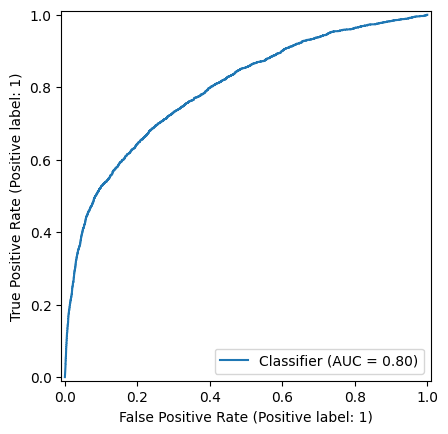

In [18]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.show()

**Conclusion**
The Logistic Regression model serves as the baseline model for predicting loan defaults. The obtained evaluation metrics will be compared against more advanced machine learning models such as XGBoost in the next notebook.

## Conclusion

The Logistic Regression model was successfully trained on the preprocessed loan default dataset.

Results:
- Accuracy: 75.55%
- Precision: 16.98%
- Recall: 68.38%
- F1 Score: 27.21%
- ROC-AUC: 79.51%

The model achieved a good ROC-AUC and high recall, indicating that it can identify a large proportion of default cases. However, the low precision suggests many false positives. This baseline model will be compared with the XGBoost model in the next notebook to determine whether a more advanced algorithm improves predictive performance.